In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import List
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

import scipy.stats as stats

from xgboost import XGBClassifier

# #1 Generating Churn Features

In [2]:
query: str = """
SELECT 
c.customer_unique_id,
AVG(oi.freight_value) AS avg_freight,
SUM(oi.price) AS total_spent,
AVG(oi.price) AS average_spent,
 AVG(
        julianday(o.order_delivered_customer_date)
        - julianday(o.order_estimated_delivery_date)
    ) AS avg_delivery_lateness,
MIN(o.order_purchase_timestamp) AS first_order_date,
MAX(o.order_purchase_timestamp) AS last_order_date,
COUNT(DISTINCT o.order_id) AS total_orders,
AVG(ore.review_score) AS avg_review_score,
COUNT(DISTINCT p.product_category_name) AS num_categories
FROM customers AS c
JOIN orders AS o 
ON c.customer_id = o.customer_id
JOIN "order reviews" AS ore 
ON o.order_id = ore.order_id
JOIN "order items" AS oi
ON o.order_id = oi.order_id
JOIN products AS p
ON oi.product_id = p.product_id
GROUP BY c.customer_unique_id
            """
conn: sqlite3.Connection = sqlite3.connect("../database/olist.db")
df: pd.DataFrame = pd.read_sql(query, conn)
conn.close()

df

,customer_unique_id,avg_freight,total_spent,average_spent,avg_delivery_lateness,first_order_date,last_order_date,total_orders,avg_review_score,num_categories
0,0000366f3b9a7992bf8c76cfdf3221e2,12.00,129.90,129.90,-4.132905,2018-05-10 10:56:27,2018-05-10 10:56:27,1,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,8.29,18.90,18.90,-4.248125,2018-05-07 11:11:27,2018-05-07 11:11:27,1,4.0,1
2,0000f46a3911fa3c0805444483337064,17.22,69.00,69.00,-1.389734,2017-03-10 21:05:03,2017-03-10 21:05:03,1,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,17.63,25.99,25.99,-11.108970,2017-10-12 20:29:41,2017-10-12 20:29:41,1,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,16.89,180.00,180.00,-7.035463,2017-11-14 19:45:42,2017-11-14 19:45:42,1,5.0,1
...,...,...,...,...,...,...,...,...,...,...
94716,fffcf5a5ff07b0908bd4e2dbc735a684,248.71,1570.00,785.00,-26.609722,2017-06-08 21:00:36,2017-06-08 21:00:36,1,5.0,1
94717,fffea47cd6d3cc0a88bd621562a9d061,19.69,64.89,64.89,-2.063657,2017-12-10 20:07:56,2017-12-10 20:07:56,1,4.0,1
94718,ffff371b4d645b6ecea244b27531430a,22.56,89.90,89.90,-29.468704,2017-02-07 15:49:16,2017-02-07 15:49:16,1,5.0,1
94719,ffff5962728ec6157033ef9805bacc48,18.69,115.00,115.00,-13.503866,2018-05-02 15:17:41,2018-05-02 15:17:41,1,5.0,1


# #2 Preprocessing and Data Cleaning

In [3]:
def handleInStorePurchases(value) -> int:
    if pd.isna(value):
        return 0
    else:
        return value


df['avg_delivery_lateness'] = df['avg_delivery_lateness'].apply(handleInStorePurchases)

df.isnull().sum()


customer_unique_id       0
avg_freight              0
total_spent              0
average_spent            0
avg_delivery_lateness    0
first_order_date         0
last_order_date          0
total_orders             0
avg_review_score         0
num_categories           0
dtype: int64

In [4]:
df["last_order_date"] = pd.to_datetime(df["last_order_date"], format="%Y-%m-%d %H:%M:%S")
df["first_order_date"] = pd.to_datetime(df["first_order_date"], format="%Y-%m-%d %H:%M:%S")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94721 entries, 0 to 94720
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_unique_id     94721 non-null  str           
 1   avg_freight            94721 non-null  float64       
 2   total_spent            94721 non-null  float64       
 3   average_spent          94721 non-null  float64       
 4   avg_delivery_lateness  94721 non-null  float64       
 5   first_order_date       94721 non-null  datetime64[us]
 6   last_order_date        94721 non-null  datetime64[us]
 7   total_orders           94721 non-null  int64         
 8   avg_review_score       94721 non-null  float64       
 9   num_categories         94721 non-null  int64         
dtypes: datetime64[us](2), float64(5), int64(2), str(1)
memory usage: 7.2 MB


In [6]:
df.describe()

,avg_freight,total_spent,average_spent,avg_delivery_lateness,first_order_date,last_order_date,total_orders,avg_review_score,num_categories
count,94721.000000,94721.000000,94721.000000,94721.000000,94721,94721,94721.000000,94721.000000,94721.000000
mean,20.222668,142.811254,126.334658,-10.957179,2017-12-31 14:59:18.827799,2018-01-03 07:01:56.166784,1.033741,4.102202,1.010895
min,0.000000,0.850000,0.850000,-146.016123,2016-09-04 21:15:19,2016-09-04 21:15:19,1.000000,1.000000,0.000000
25%,13.370000,47.900000,42.900000,-16.174572,2017-09-12 15:35:32,2017-09-15 23:12:17,1.000000,4.000000,1.000000
50%,16.393333,89.900000,79.000000,-11.388137,2018-01-19 13:20:49,2018-01-22 17:08:22,1.000000,5.000000,1.000000
75%,21.210000,155.960000,139.900000,-6.231458,2018-05-04 20:02:03,2018-05-07 12:46:18,1.000000,5.000000,1.000000
max,409.680000,13440.000000,6735.000000,188.975081,2018-08-29 15:00:37,2018-09-03 09:06:57,16.000000,5.000000,5.000000
std,15.816026,217.714921,190.410031,10.097592,NaN,NaN,0.210527,1.326758,0.204952


In [7]:
currentDate: pd.Timestamp = pd.to_datetime("2026-06-19 00:00:00") 

reference_date: pd.Timestamp = df["last_order_date"].max()

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94721 entries, 0 to 94720
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_unique_id     94721 non-null  str           
 1   avg_freight            94721 non-null  float64       
 2   total_spent            94721 non-null  float64       
 3   average_spent          94721 non-null  float64       
 4   avg_delivery_lateness  94721 non-null  float64       
 5   first_order_date       94721 non-null  datetime64[us]
 6   last_order_date        94721 non-null  datetime64[us]
 7   total_orders           94721 non-null  int64         
 8   avg_review_score       94721 non-null  float64       
 9   num_categories         94721 non-null  int64         
dtypes: datetime64[us](2), float64(5), int64(2), str(1)
memory usage: 7.2 MB


In [9]:
df['churn'] = np.where((reference_date - df["last_order_date"]).dt.days > 180, 1, 0)

# #3 Training and Hypertuning

In [10]:
X: pd.DataFrame = df.drop(columns=["churn", "customer_unique_id", "total_orders"])
y: pd.Series = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
categorical_cols: List[str | object] = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols: List[int | float] = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor: ColumnTransformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols)
    ]
)

In [12]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

pipe: Pipeline = Pipeline(steps =[
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

In [13]:
model: Pipeline = pipe.fit(X_train, y_train)

In [14]:
param_dist = {
    'classifier__max_depth': stats.randint(3, 10),
    'classifier__learning_rate': stats.uniform(0.01, 0.1),
    'classifier__subsample': stats.uniform(0.5, 0.5),
    'classifier__n_estimators':stats.randint(50, 200)
}

In [15]:
improved_model = RandomizedSearchCV(estimator=pipe, param_distributions=param_dist,  cv=5, scoring='accuracy', n_jobs=1, verbose=1)

In [16]:
improved_model.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': <scipy.stats....00236BCB0CEC0>, 'classifier__max_depth': <scipy.stats....00236BCB0CAD0>, 'classifier__n_estimators': <scipy.stats....00236BBA78410>, 'classifier__subsample': <scipy.stats....00236BBA78190>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the sa

# #4 Evaluation

In [17]:
best_model: Pipeline = improved_model.best_estimator_

y_pred: np.ndarray = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78      7549
           1       0.84      0.90      0.87     11396

    accuracy                           0.83     18945
   macro avg       0.83      0.82      0.82     18945
weighted avg       0.83      0.83      0.83     18945



In [18]:
result = permutation_importance(improved_model, X_test, y_test, n_repeats=10, random_state=42)

importances: pd.Series = pd.Series(result.importances_mean, index=X_test.columns)
print(importances.sort_values(ascending=False))

avg_freight              0.294838
average_spent            0.106492
total_spent              0.039002
avg_delivery_lateness    0.011840
num_categories           0.002069
avg_review_score         0.001103
last_order_date          0.000000
first_order_date         0.000000
dtype: float64


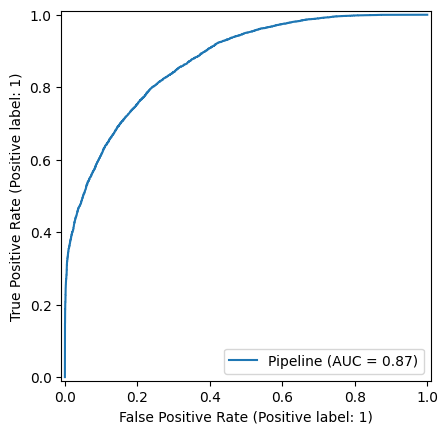

In [19]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()
